# Signals in Time and Frequency

The **Fourier transform** maps a signal $x(t)$ to its spectral description $X(f)$:

$$X(f) = \int_{-\infty}^{+\infty} x(t)\,e^{-j2\pi f t}\,dt
\qquad\longleftrightarrow\qquad
x(t) = \int_{-\infty}^{+\infty} X(f)\,e^{+j2\pi f t}\,df$$

Two properties govern how parameter changes ripple through the transform pair:

| Property | Time domain | Frequency domain |
|----------|-------------|------------------|
| **Scaling / Duality** | $x(t/a)$, width $\times a$ | $\|a\|\,X(af)$, width $\times 1/a$ |
| **Time shift** | $x(t - t_0)$ | $e^{-j2\pi f t_0}\,X(f)$ — magnitude **unchanged** |
| **Amplitude** | $A\,x(t)$ | $A\,X(f)$ — linear scaling |

Five classical signal families are explored below with interactive sliders.

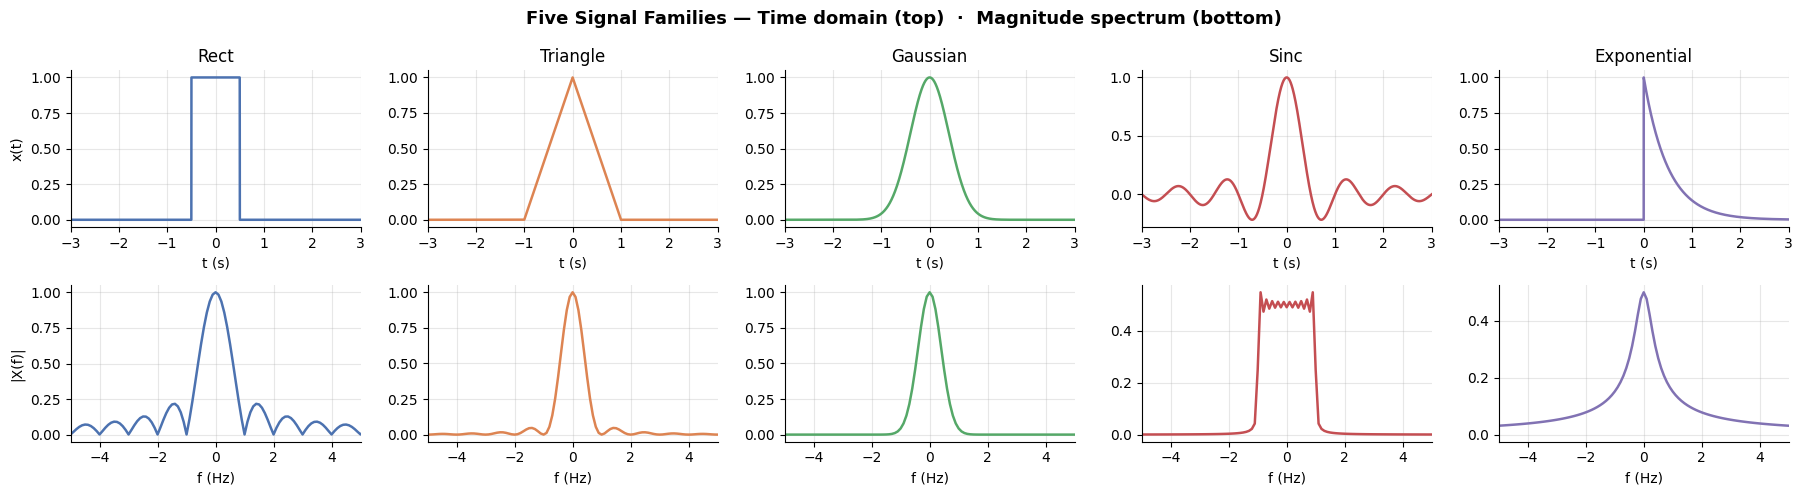

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

N     = 8192
T_MAX = 10.0
t     = np.linspace(-T_MAX / 2, T_MAX / 2, N)
dt    = t[1] - t[0]

def spectrum(x):
    """Return (frequency axis, magnitude spectrum) via FFT."""
    X = np.fft.fftshift(np.fft.fft(x)) * dt
    f = np.fft.fftshift(np.fft.fftfreq(N, dt))
    return f, np.abs(X)

_families = {
    "Rect":        (lambda s: np.where(np.abs(s) <= 0.5, 1.0, 0.0),      "#4C72B0"),
    "Triangle":    (lambda s: np.maximum(0.0, 1.0 - np.abs(s)),           "#DD8452"),
    "Gaussian":    (lambda s: np.exp(-np.pi * s ** 2),                    "#55A868"),
    "Sinc":        (lambda s: np.sinc(2 * s),                             "#C44E52"),
    "Exponential": (lambda s: np.where(s >= 0, np.exp(-2 * s), 0.0),      "#8172B3"),
}

fig, axes = plt.subplots(2, 5, figsize=(18, 5))
for col, (name, (fn, color)) in enumerate(_families.items()):
    x = fn(t)
    f, Xmag = spectrum(x)
    axes[0, col].plot(t,    x,    color=color, lw=1.8)
    axes[0, col].set(xlim=(-3, 3), title=name, xlabel="t (s)")
    axes[1, col].plot(f, Xmag,    color=color, lw=1.8)
    axes[1, col].set(xlim=(-5, 5), xlabel="f (Hz)")

axes[0, 0].set_ylabel("x(t)")
axes[1, 0].set_ylabel("|X(f)|")
fig.suptitle("Five Signal Families — Time domain (top)  ·  Magnitude spectrum (bottom)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Rectangular Pulse

$$\mathrm{rect}\!\left(\frac{t - t_0}{\tau}\right)
= A \cdot \mathbf{1}_{\{|t - t_0| \leq \tau/2\}}$$

Fourier transform pair:

$$\boxed{X(f) = A\tau\;\operatorname{sinc}(f\tau)\;e^{-j2\pi f t_0}}
\qquad\text{where}\quad \operatorname{sinc}(u) \equiv \frac{\sin(\pi u)}{\pi u}$$

| Parameter change | Time effect | Spectral effect |
|-----------------|-------------|-----------------|
| $\tau$ ↑  (wider) | wider gate | narrower lobe, higher peak $A\tau$, first null moves to $1/\tau$ |
| $A$ ↑ | taller gate | spectrum scales uniformly |
| $t_0 \neq 0$ | pulse shifts | linear phase $e^{-j2\pi f t_0}$; magnitude $|X|$ **unchanged** |

Sidelobe decay: $|X| \sim 1/f$ — relatively slow, driven by the signal's **abrupt edges**.

In [2]:
def _plot_rect(A=1.0, tau=1.0, t0=0.0):
    x = A * np.where(np.abs(t - t0) <= tau / 2, 1.0, 0.0)
    f, Xmag = spectrum(x)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(t, x, "#4C72B0", lw=2)
    ax1.set(xlim=(-5, 5), ylim=(-0.3, 3.5),
            xlabel="t (s)", ylabel="x(t)", title="Rectangular Pulse — Time Domain")
    ax1.axhline(0, color="k", lw=0.5)
    ax1.axvline(0, color="k", lw=0.5, ls="--", alpha=0.4)

    ax2.plot(f, Xmag, "tomato", lw=2)
    ax2.set(xlim=(-8, 8), ylim=(-0.05, None),
            xlabel="f (Hz)", ylabel="|X(f)|", title="Magnitude Spectrum")
    ax2.axhline(0, color="k", lw=0.5)
    ax2.axvline(0, color="k", lw=0.5, ls="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

interact(_plot_rect,
    A   = FloatSlider(1.0, min=0.1, max=3.0, step=0.1,  description="A (ampl.)"),
    tau = FloatSlider(1.0, min=0.1, max=4.0, step=0.1,  description="τ  (width)"),
    t0  = FloatSlider(0.0, min=-3.0, max=3.0, step=0.1, description="t₀ (shift)"),
)


interactive(children=(FloatSlider(value=1.0, description='A (ampl.)', max=3.0, min=0.1), FloatSlider(value=1.0…

<function __main__._plot_rect(A=1.0, tau=1.0, t0=0.0)>

## Triangular Pulse

$$\Lambda\!\left(\frac{t - t_0}{\tau}\right)
= A \cdot \max\!\left(0,\; 1 - \frac{|t - t_0|}{\tau}\right)$$

The triangle is the **self-convolution of a rectangular pulse** ($\Lambda = \Pi * \Pi$).
By the convolution theorem its spectrum is therefore a **squared sinc**:

$$\boxed{X(f) = A\tau\;\operatorname{sinc}^2\!\!\left(\frac{f\tau}{2}\right) e^{-j2\pi f t_0}}$$

Contrast with the rect of the same total width:

| Property | Rect | Triangle |
|----------|------|---------|
| First null | $1/\tau$ | $2/\tau$ (lobe twice as wide) |
| Sidelobe decay | $\sim 1/f$ | $\sim 1/f^2$ — **much lower leakage** |
| Discontinuities | sharp edges | none (continuous, non-smooth) |

**Smoother edges in time → faster spectral roll-off** — a universal design principle.

In [ ]:
def _plot_triangle(A=1.0, tau=1.0, t0=0.0):
    x = A * np.maximum(0.0, 1.0 - np.abs(t - t0) / tau)
    f, Xmag = spectrum(x)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(t, x, "#DD8452", lw=2)
    ax1.set(xlim=(-5, 5), ylim=(-0.3, 3.5),
            xlabel="t (s)", ylabel="x(t)", title="Triangular Pulse — Time Domain")
    ax1.axhline(0, color="k", lw=0.5)
    ax1.axvline(0, color="k", lw=0.5, ls="--", alpha=0.4)

    ax2.plot(f, Xmag, "tomato", lw=2)
    ax2.set(xlim=(-8, 8), ylim=(-0.05, None),
            xlabel="f (Hz)", ylabel="|X(f)|", title="Magnitude Spectrum")
    ax2.axhline(0, color="k", lw=0.5)

    plt.tight_layout()
    plt.show()

interact(_plot_triangle,
    A   = FloatSlider(1.0, min=0.1, max=3.0, step=0.1,  description="A (ampl.)"),
    tau = FloatSlider(1.0, min=0.1, max=4.0, step=0.1,  description="τ (half-width)"),
    t0  = FloatSlider(0.0, min=-3.0, max=3.0, step=0.1, description="t₀ (shift)"),
)


interactive(children=(FloatSlider(value=1.0, description='A (ampl.)', max=3.0, min=0.1), FloatSlider(value=1.0…

<function __main__._plot_triangle(A=1.0, tau=1.0, t0=0.0)>

## Gaussian Pulse

$$g(t) = A \exp\!\left(-\frac{(t - t_0)^2}{2\sigma^2}\right)$$

The Gaussian is **self-dual under the Fourier transform**: its spectrum is also a Gaussian.

$$\boxed{X(f) = A\,\sigma\sqrt{2\pi}\;\exp\!\left(-2\pi^2\sigma^2 f^2\right)\;e^{-j2\pi f t_0}}$$

RMS time spread $\sigma_t = \sigma$;  RMS frequency spread $\sigma_f = \dfrac{1}{2\pi\sigma}$.

The Gaussian achieves the **Heisenberg–Gabor minimum**:

$$\sigma_t \cdot \sigma_f \;=\; \frac{1}{4\pi} \;\approx\; 0.0796$$

No signal can be simultaneously more concentrated in both time and frequency.
Observe: increasing $\sigma$ widens the pulse and *compresses* the spectrum — duality in its purest form.

In [4]:
def _plot_gaussian(A=1.0, sigma=0.5, t0=0.0):
    x = A * np.exp(-((t - t0) ** 2) / (2 * sigma ** 2))
    f, Xmag = spectrum(x)

    sigma_f = 1.0 / (2 * np.pi * sigma)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(t, x, "#55A868", lw=2)
    ax1.set(xlim=(-5, 5), ylim=(-0.3, 3.5),
            xlabel="t (s)", ylabel="x(t)",
            title=f"Gaussian Pulse  (sigma_t = {sigma:.2f} s)")
    ax1.axhline(0, color="k", lw=0.5)
    ax1.axvline(0, color="k", lw=0.5, ls="--", alpha=0.4)

    ax2.plot(f, Xmag, "tomato", lw=2)
    ax2.set(xlim=(-5, 5), ylim=(-0.05, None),
            xlabel="f (Hz)", ylabel="|X(f)|",
            title=f"Magnitude Spectrum  (sigma_f = {sigma_f:.3f} Hz,  product = {sigma*sigma_f:.4f})")
    ax2.axhline(0, color="k", lw=0.5)

    plt.tight_layout()
    plt.show()

interact(_plot_gaussian,
    A     = FloatSlider(1.0, min=0.1, max=3.0,  step=0.1,  description="A (ampl.)"),
    sigma = FloatSlider(0.5, min=0.05, max=3.0, step=0.05, description="sigma (width)"),
    t0    = FloatSlider(0.0, min=-3.0, max=3.0,  step=0.1,  description="t0 (shift)"),
)


interactive(children=(FloatSlider(value=1.0, description='A (ampl.)', max=3.0, min=0.1), FloatSlider(value=0.5…

<function __main__._plot_gaussian(A=1.0, sigma=0.5, t0=0.0)>

## Sinc Function

The sinc is the **Fourier dual of the rectangular pulse**: a hard rectangular band in frequency
corresponds to an oscillating sinc function in time.

$$x(t) = A \cdot \operatorname{sinc}\!\left(2W(t - t_0)\right)
= A \cdot \frac{\sin\!\left(2\pi W(t - t_0)\right)}{2\pi W(t - t_0)}$$

Its spectrum is an **ideal low-pass filter** with one-sided bandwidth $W$:

$$\boxed{X(f) = \frac{A}{2W}\;\mathrm{rect}\!\left(\frac{f}{2W}\right)
= \begin{cases} A/(2W) & |f| \leq W \\ 0 & |f| > W \end{cases}}$$

- **Infinite time support** — physically unrealizable; requires $t \in (-\infty, +\infty)$
- Increasing $W$ widens the flat spectral band and *compresses* the sinc in time (sidelobes crowd together)
- Since the grid is finite the sinc is implicitly windowed: push $t_0$ to the edge and watch **Gibbs oscillations** appear in the spectrum

In [ ]:
def _plot_sinc(A=1.0, W=1.0, t0=0.0):
    x = A * np.sinc(2 * W * (t - t0))
    f, Xmag = spectrum(x)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(t, x, "#C44E52", lw=2)
    ax1.set(xlim=(-5, 5), ylim=(-1.5, 3.5),
            xlabel="t (s)", ylabel="x(t)", title="Sinc Function — Time Domain")
    ax1.axhline(0, color="k", lw=0.5)
    ax1.axvline(0, color="k", lw=0.5, ls="--", alpha=0.4)

    ax2.plot(f, Xmag, "tomato", lw=2)
    ax2.set(xlim=(-8, 8), ylim=(-0.02, None),
            xlabel="f (Hz)", ylabel="|X(f)|",
            title=f"Magnitude Spectrum  (ideal bandwidth = {W:.1f} Hz)")
    ax2.axhline(0, color="k", lw=0.5)

    plt.tight_layout()
    plt.show()

interact(_plot_sinc,
    A  = FloatSlider(1.0, min=0.1, max=3.0, step=0.1,  description="A (ampl.)"),
    W  = FloatSlider(1.0, min=0.1, max=4.0, step=0.1,  description="W (BW, Hz)"),
    t0 = FloatSlider(0.0, min=-3.0, max=3.0, step=0.1, description="t0 (shift)"),
)


## One-Sided Exponential

The causal decaying exponential is the impulse response of every first-order LTI system:

$$x(t) = A\,e^{-\lambda(t - t_0)}\,u(t - t_0), \qquad \lambda > 0$$

where $u$ is the unit step. Its Fourier transform is a **Lorentzian**:

$$\boxed{X(f) = \frac{A\,e^{-j2\pi f t_0}}{\lambda + j2\pi f}
\qquad\Rightarrow\qquad
|X(f)| = \frac{A}{\sqrt{\lambda^2 + (2\pi f)^2}}}$$

| Quantity | Formula |
|----------|---------|
| DC peak | $|X(0)| = A/\lambda$ |
| $-3\ \text{dB}$ bandwidth | $f_{3\text{dB}} = \lambda/(2\pi)$ |
| Roll-off at high $f$ | $20\ \text{dB/decade}$ |

Increasing $\lambda$ speeds the decay **and** broadens the Lorentzian — directly analogous to rect/sinc duality.

In [ ]:
def _plot_exponential(A=1.0, lam=1.0, t0=0.0):
    x = A * np.where(t >= t0, np.exp(-lam * (t - t0)), 0.0)
    f, Xmag = spectrum(x)

    f3db = lam / (2 * np.pi)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(t, x, "#8172B3", lw=2)
    ax1.set(xlim=(-5, 5), ylim=(-0.3, 3.5),
            xlabel="t (s)", ylabel="x(t)", title="One-Sided Exponential — Time Domain")
    ax1.axhline(0, color="k", lw=0.5)
    ax1.axvline(0, color="k", lw=0.5, ls="--", alpha=0.4)

    ax2.plot(f, Xmag, "tomato", lw=2)
    ax2.axvline( f3db, color="#8172B3", lw=1.2, ls="--",
                label=f"f_3dB = {f3db:.2f} Hz")
    ax2.axvline(-f3db, color="#8172B3", lw=1.2, ls="--")
    ax2.legend(fontsize=9)
    ax2.set(xlim=(-6, 6), ylim=(-0.05, None),
            xlabel="f (Hz)", ylabel="|X(f)|",
            title="Magnitude Spectrum (Lorentzian)")
    ax2.axhline(0, color="k", lw=0.5)

    plt.tight_layout()
    plt.show()

interact(_plot_exponential,
    A   = FloatSlider(1.0, min=0.1, max=3.0, step=0.1,  description="A (ampl.)"),
    lam = FloatSlider(1.0, min=0.1, max=5.0, step=0.1,  description="lambda (decay)"),
    t0  = FloatSlider(0.0, min=-3.0, max=2.0, step=0.1, description="t0 (onset)"),
)


## Linear Frequency-Swept Signal (Chirp)

A **chirp** sweeps its instantaneous frequency linearly across a wide bandwidth:

$$x(t) = A\;\mathrm{rect}\!\left(\frac{t}{T}\right)\cos\!\left(2\pi\!\left(f_0\,t + \frac{\mu}{2}\,t^2\right)\right)
\qquad \mu = \frac{f_1 - f_0}{T}$$

The **instantaneous frequency** $f_i(t) = f_0 + \mu\,t$ sweeps from $f_0$ to $f_1$ over duration $T$.

By the stationary-phase approximation the magnitude spectrum is approximately flat over the swept band:

$$|X(f)| \;\approx\; \frac{A}{\sqrt{|\mu|}}\;\mathrm{rect}\!\!\left(\frac{f - \bar{f}}{f_1 - f_0}\right),
\qquad \bar{f} = \frac{f_0 + f_1}{2}$$

The **time–bandwidth product** $TB = T|f_1 - f_0|$ (shown in the title) quantifies the signal's spread:
large $TB$ enables **pulse compression** — a matched filter collapses the chirp to a narrow peak of width ${\approx}1/B$.

In [ ]:
def _plot_chirp(A=1.0, f0=1.0, f1=5.0, T=4.0):
    gate = np.where(np.abs(t) <= T / 2, 1.0, 0.0)
    mu   = (f1 - f0) / max(T, 1e-9)
    phi  = 2 * np.pi * (f0 * t + 0.5 * mu * t ** 2)
    x    = A * gate * np.cos(phi)
    f_ax, Xmag = spectrum(x)

    TB = T * abs(f1 - f0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(t, x, "#BCB37F", lw=1.4)
    ax1.set(xlim=(-5, 5), ylim=(-3.5, 3.5),
            xlabel="t (s)", ylabel="x(t)",
            title=f"Linear Chirp  (f0={f0:.1f} Hz  to  f1={f1:.1f} Hz,  T={T:.1f} s)")
    ax1.axhline(0, color="k", lw=0.5)

    ax2.plot(f_ax, Xmag, "tomato", lw=2)
    ax2.set(xlim=(-12, 12), ylim=(-0.05, None),
            xlabel="f (Hz)", ylabel="|X(f)|",
            title=f"Magnitude Spectrum  (TB = {TB:.1f})")
    ax2.axhline(0, color="k", lw=0.5)

    plt.tight_layout()
    plt.show()

interact(_plot_chirp,
    A  = FloatSlider(1.0, min=0.1, max=3.0, step=0.1, description="A (ampl.)"),
    f0 = FloatSlider(1.0, min=0.5, max=8.0, step=0.5, description="f0 (start Hz)"),
    f1 = FloatSlider(5.0, min=0.5, max=8.0, step=0.5, description="f1 (end Hz)"),
    T  = FloatSlider(4.0, min=0.5, max=8.0, step=0.5, description="T (duration s)"),
)


interactive(children=(FloatSlider(value=1.0, description='A (ampl.)', max=3.0, min=0.1), FloatSlider(value=1.0…

<function __main__._plot_chirp(A=1.0, f0=1.0, f1=5.0, T=4.0)>

## Time–Bandwidth Product and the Uncertainty Principle

Define the RMS spreads in time and frequency:

$$\sigma_t^2 = \frac{\int t^2\,|x(t)|^2\,dt}{\int |x(t)|^2\,dt}
\qquad\qquad
\sigma_f^2 = \frac{\int f^2\,|X(f)|^2\,df}{\int |X(f)|^2\,df}$$

The **Heisenberg–Gabor inequality** is fundamental and inescapable:

$$\boxed{\sigma_t \cdot \sigma_f \;\geq\; \frac{1}{4\pi} \;\approx\; 0.0796}$$

| Signal | $\sigma_t \cdot \sigma_f \;\big/\; \tfrac{1}{4\pi}$ | Notes |
|--------|:---:|------|
| **Gaussian** | **1.00** | unique minimizer — no sidelobes |
| Triangular | ≈ 1.56 | smooth; lower leakage than rect |
| Rectangular | ≈ 1.81 | abrupt edges drive sinc sidelobes |
| Sinc (truncated) | 1 → ∞ | depends on window length |

The panel below places all four families on a **shared scale parameter** $\tau$ so spectra can be compared directly.
Each subplot title shows the numerically computed ratio $\sigma_t \sigma_f / (1/4\pi)$.

In [8]:
def _tb_product(t, x, f, Xmag):
    Ex = np.trapezoid(x ** 2, t)
    Ef = np.trapezoid(Xmag ** 2, f)
    if Ex < 1e-12 or Ef < 1e-12:
        return float("nan")
    t_mean  = np.trapezoid(t * x ** 2, t) / Ex
    f_mean  = np.trapezoid(f * Xmag ** 2, f) / Ef
    sigma_t = np.sqrt(np.trapezoid((t - t_mean) ** 2 * x ** 2,    t) / Ex)
    sigma_f = np.sqrt(np.trapezoid((f - f_mean) ** 2 * Xmag ** 2, f) / Ef)
    return sigma_t * sigma_f

def _plot_comparison(tau=1.0):
    sigs = [
        ("Rect",     np.where(np.abs(t) <= tau / 2, 1.0, 0.0),             "#4C72B0"),
        ("Triangle", np.maximum(0.0, 1.0 - np.abs(t) / tau),               "#DD8452"),
        ("Gaussian", np.exp(-(t ** 2) / (2 * (tau / 2.355) ** 2)),         "#55A868"),
        ("Sinc",     np.sinc(t / tau),                                      "#C44E52"),
    ]
    heisenberg = 1.0 / (4 * np.pi)

    fig, axes = plt.subplots(2, 4, figsize=(18, 6))
    for col, (name, x, col_color) in enumerate(sigs):
        f_ax, Xmag = spectrum(x)
        tb    = _tb_product(t, x, f_ax, Xmag)
        ratio = tb / heisenberg

        axes[0, col].plot(t,    x,    color=col_color, lw=2)
        axes[0, col].set(xlim=(-4, 4), ylim=(-0.6, 1.8),
                         title=f"{name}\n"
                               r"$\sigma_t \sigma_f\,/\,(1/4\pi)$" +
                               f" = {ratio:.2f}",
                         xlabel="t (s)")
        axes[0, col].axhline(0, color="k", lw=0.4)

        axes[1, col].plot(f_ax, Xmag, color=col_color, lw=2)
        axes[1, col].set(xlim=(-6, 6), xlabel="f (Hz)")
        axes[1, col].axhline(0, color="k", lw=0.4)

    axes[0, 0].set_ylabel("x(t)")
    axes[1, 0].set_ylabel("|X(f)|")
    fig.suptitle(
        f"Four Families — Common Scale  tau = {tau:.2f} s   "
        f"(Heisenberg bound = 1/4pi ~ {heisenberg:.4f})",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

interact(_plot_comparison,
    tau = FloatSlider(1.0, min=0.2, max=4.0, step=0.1, description="tau (scale)"),
)


interactive(children=(FloatSlider(value=1.0, description='tau (scale)', max=4.0, min=0.2), Output()), _dom_cla…

<function __main__._plot_comparison(tau=1.0)>